# 🎙️ Pipeline Prétraitement & Augmentation — Whisper

**Objectif :** Prendre en charge des paires audio-texte brutes, filtrer les données de mauvaise qualité, isoler la voix, et augmenter les données pour le fine-tuning Whisper.

## Architecture

```
INPUT : Paires (audio .wav/.mp3, texte) brutes
  │
  ├── ZONE A : Normalisation audio
  │     └── Conversion 16kHz mono, normalisation volume
  │
  ├── ZONE B : Séparation source — Focus voix  [v2]
  │     ├── audio-separator / MDX-Net (GPU/CPU) → isole la piste vocale
  │     └── Demucs htdemucs_ft (fallback)       → séparation alternative
  │     ⚠️  noisereduce RETIRÉ (non adapté à la séparation vocale réelle)
  │
  ├── ZONE C : Filtres de qualité  [v2]
  │     ├── Durée (min / max)
  │     ├── SNR — Signal-to-Noise Ratio
  │     ├── RMS — énergie (silence / saturation)
  │     ├── VAD — Voice Activity Detection (couvre aussi les silences)
  │     └── Confiance Whisper optionnelle (avg_logprob / compression_ratio)
  │     ⚠️  WER RETIRÉ (coûteux, redondant, biais transcription)
  │
  ├── ZONE D : Augmentation des données  [v2 — automatique]
  │     └── audiomentations (SomeOf 2 transformations aléatoires) :
  │           AddGaussianSNR, AddColoredNoise, RoomSimulator,
  │           TimeStretch, PitchShift, Gain, Mp3Compression
  │     ⚠️  Code manuel remplacé par audiomentations (open-source, maintenu)
  │
  └── ZONE E : Export JSONL
        └── Données prêtes pour fine-tuning Whisper
```

---
## Zone 0 : Installation & Configuration

In [ ]:
!apt-get install -y ffmpeg > /dev/null 2>&1

!pip uninstall -y audiomentations
!pip install -q --upgrade audiomentations \
    audio-separator \
    onnxruntime-gpu \
    librosa \
    soundfile \
    tqdm \
    numpy \
    pandas \
    matplotlib \
    scipy

!pip install -q transformers openai-whisper

# Force Python à voir les packages fraîchement installés
import sys, site
sys.path.insert(0, site.getsitepackages()[0])

print('✅ Installation terminée')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 18.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.6/405.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json
import shutil
import subprocess
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
print(f'Device   : {DEVICE}')

try:
    from audio_separator.separator import Separator
    print("✅ audio-separator disponible")
except ImportError as e:
    print(f"❌ audio-separator introuvable — redémarre le runtime Colab : {e}")

PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : cuda
✅ audio-separator disponible


In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# Diagnostic: Check audiomentations version
import audiomentations
print(f"audiomentations version: {audiomentations.__version__}")

Mounted at /content/drive
audiomentations version: 0.43.1


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  CONFIGURATION — Adapter selon ton environnement
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Entrée ───────────────────────────────────────────────────────────────
    "input_audio_dir"    : Path("/content/drive/MyDrive/asr/data/raw_audio"),
    "input_jsonl"        : Path("/content/drive/MyDrive/asr/output/input_pairs.jsonl"),
    "input_mode"         : "jsonl",   # 'jsonl' ou 'folder'

    # ── Sorties ──────────────────────────────────────────────────────────────
    "output_dir"         : Path("/content/drive/MyDrive/asr/output_2/preprocessed"),
    "voice_dir"          : Path("/content/drive/MyDrive/asr/output_2/voice_separated"),
    "augmented_dir"      : Path("/content/drive/MyDrive/asr/output_2/augmented"),

    # ── Audio ────────────────────────────────────────────────────────────────
    "sample_rate"        : 16000,
    "audio_extensions"   : [".wav", ".mp3", ".m4a", ".flac", ".ogg"],

    # ── Zone B : Séparation source ───────────────────────────────────────────
    # audio-separator (MDX-Net / Demucs v4), remplace l'ancien demucs standalone
    "use_source_separation" : True,

    # ── Zone C : Filtres de qualité ──────────────────────────────────────────
    "min_duration_sec"   : 1.0,
    "max_duration_sec"   : 30.0,
    "min_snr_db"         : 10.0,
    "min_rms_db"         : -40.0,
    "max_rms_db"         : -3.0,
    "min_vad_ratio"      : 0.30,

    # WER retiré — remplacé par un score de confiance Whisper plus léger.
    # Mettre use_whisper_confidence=True pour activer (désactivé par défaut).
    "use_whisper_confidence" : False,
    "min_avg_logprob"        : -1.0,   # Seuil log-prob moyen (ex : -1.0)
    "max_compression_ratio"  : 2.4,    # Seuil répétitions Whisper
    "whisper_model"          : "base",
    "language"               : "fr",

    # ── Zone D : Augmentation (audiomentations) ──────────────────────────────
    "augmentation_factor": 3,     # Versions augmentées par segment original
    "snr_range_db"       : (5, 20),
    "speed_range"        : (0.9, 1.1),
    "pitch_range_steps"  : (-2, 2),
}

for key in ["output_dir", "voice_dir", "augmented_dir"]:
    CONFIG[key].mkdir(parents=True, exist_ok=True)

print('✅ Configuration chargée')

✅ Configuration chargée


### Chargement des paires audio-texte

In [ ]:
def load_pairs_from_jsonl(jsonl_path: Path) -> List[Dict]:
    """
    Charge des paires depuis un fichier JSONL.
    Format attendu par ligne :
        {"audio_path": "/path/to/file.wav", "text": "transcription", "id": "optionnel"}
    """
    pairs = []
    missing = 0
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            d = json.loads(line)
            audio_path = Path(d['audio_path'])
            if not audio_path.exists():
                missing += 1
                continue
            pairs.append({
                'id'         : d.get('id', f'seg_{i:05d}'),
                'audio_path' : audio_path,
                'text'       : d.get('text', '').strip(),
                'speaker'    : d.get('speaker', 'unknown'),
                'metadata'   : {k: v for k, v in d.items()
                                if k not in ('audio_path', 'text', 'id', 'speaker')}
            })
    print(f'✅ Paires chargées  : {len(pairs)}')
    if missing:
        print(f'⚠️  Audio manquant  : {missing}')
    return pairs


def load_pairs_from_folder(audio_dir: Path, extensions: List[str]) -> List[Dict]:
    """
    Charge des paires depuis un dossier.
    Pour chaque fichier audio, cherche un .txt ou .json du même nom.
    """
    pairs = []
    no_text = []
    for ext in extensions:
        for audio_path in sorted(audio_dir.rglob(f'*{ext}')):
            txt_path  = audio_path.with_suffix('.txt')
            json_path = audio_path.with_suffix('.json')
            if txt_path.exists():
                text = txt_path.read_text(encoding='utf-8').strip()
            elif json_path.exists():
                text = json.loads(json_path.read_text())['text']
            else:
                no_text.append(audio_path.name)
                continue
            pairs.append({
                'id'        : audio_path.stem,
                'audio_path': audio_path,
                'text'      : text,
                'speaker'   : 'unknown',
                'metadata'  : {}
            })
    print(f'✅ Paires chargées  : {len(pairs)}')
    if no_text:
        print(f'⚠️  Sans texte ignoré: {len(no_text)}')
    return pairs


# ── Chargement selon le mode configuré ────────────────────────────────────
if CONFIG['input_mode'] == 'jsonl':
    raw_pairs = load_pairs_from_jsonl(CONFIG['input_jsonl'])
else:
    raw_pairs = load_pairs_from_folder(
        CONFIG['input_audio_dir'], CONFIG['audio_extensions']
    )

print(f'   Exemple : {raw_pairs[0] if raw_pairs else "(vide)"}')

✅ Paires chargées  : 55
   Exemple : {'id': 'merged_01-1b_SOF_0000', 'audio_path': PosixPath('/content/drive/MyDrive/asr/output/merged_segments/audio/SOF/merged_01-1b_SOF_0000.wav'), 'text': "l'escargot dort parc(e) qu'il fait beau dehors un nuage arrive et fait tomber la pluie l'escargot sort une corne deux cornes et s'en va se promener", 'speaker': 'SOF', 'metadata': {'source_file': '01-1b', 'source_audio': '/content/drive/MyDrive/asr/data/songs/1/01-1b.mp3', 'duration_sec': 20.129, 'num_words': 26, 'word_times': [{'word': "l'escargot", 'start_ms': 0.0, 'end_ms': 680.0}, {'word': 'dort', 'start_ms': 760.0, 'end_ms': 1341.0}, {'word': 'parc(e)', 'start_ms': 2442.0, 'end_ms': 2922.0}, {'word': "qu'il", 'start_ms': 2922.0, 'end_ms': 3082.0}, {'word': 'fait', 'start_ms': 3242.0, 'end_ms': 3463.0}, {'word': 'beau', 'start_ms': 3523.0, 'end_ms': 3763.0}, {'word': 'dehors', 'start_ms': 3863.0, 'end_ms': 4363.0}, {'word': 'un', 'start_ms': 7066.0, 'end_ms': 7126.0}, {'word': 'nuage', 'start_

---
## Zone A : Normalisation audio
Conversion de tous les fichiers vers **16kHz mono WAV** et normalisation du volume.

In [ ]:
def normalize_audio(audio: np.ndarray, target_db: float = -20.0) -> np.ndarray:
    """
    Normalise le volume d'un signal audio vers un niveau RMS cible (dBFS).
    Évite la saturation et les signaux quasi-silencieux.
    """
    rms = np.sqrt(np.mean(audio ** 2))
    if rms < 1e-10:
        return audio
    target_rms = 10 ** (target_db / 20)
    gain = target_rms / rms
    return np.clip(audio * gain, -1.0, 1.0)


def load_and_normalize(audio_path: Path, sr: int = 16000) -> Optional[np.ndarray]:
    """Charge un fichier audio en 16kHz mono et normalise le volume."""
    try:
        audio, _ = librosa.load(str(audio_path), sr=sr, mono=True)
        audio = normalize_audio(audio)
        return audio.astype(np.float32)
    except Exception as e:
        print(f'  ⚠️  Erreur chargement {audio_path.name}: {e}')
        return None


def convert_to_wav(audio_path: Path, out_dir: Path, sr: int = 16000) -> Optional[Path]:
    """Convertit n'importe quel format audio vers WAV 16kHz mono via ffmpeg."""
    out_path = out_dir / (audio_path.stem + '.wav')
    if out_path.exists():
        return out_path
    cmd = [
        'ffmpeg', '-i', str(audio_path),
        '-ar', str(sr), '-ac', '1',
        '-acodec', 'pcm_s16le',
        '-y', str(out_path)
    ]
    try:
        subprocess.run(cmd, check=True, capture_output=True, timeout=30)
        return out_path
    except Exception as e:
        print(f'  ⚠️  ffmpeg error {audio_path.name}: {e}')
        return None


def normalize_batch(pairs: List[Dict], out_dir: Path,
                    sr: int = 16000) -> List[Dict]:
    """Normalise tous les fichiers audio du dataset."""
    print('=' * 70)
    print('ZONE A : NORMALISATION AUDIO')
    print('=' * 70)

    norm_dir = out_dir / 'normalized'
    norm_dir.mkdir(exist_ok=True)
    results = []
    failed = 0

    for pair in tqdm(pairs, desc='Normalisation'):
        audio_path = Path(pair['audio_path'])
        out_path = norm_dir / (pair['id'] + '.wav')

        if not out_path.exists():
            audio = load_and_normalize(audio_path, sr=sr)
            if audio is None:
                failed += 1
                continue
            sf.write(str(out_path), audio, sr, subtype='PCM_16')

        p = dict(pair)
        p['audio_path'] = out_path
        results.append(p)

    print(f'\n   ✅ Normalisés  : {len(results)}')
    if failed:
        print(f'   ❌ Échecs      : {failed}')
    return results


pairs_normalized = normalize_batch(
    raw_pairs, CONFIG['output_dir'], CONFIG['sample_rate']
)

ZONE A : NORMALISATION AUDIO


Normalisation: 100%|██████████| 55/55 [00:39<00:00,  1.39it/s]


   ✅ Normalisés  : 55


---
## Zone B : Séparation source — Focus voix

**audio-separator** (wrapper unifié UVR / MDX-Net / Demucs) isole la piste vocale
en supprimant musique, bruits de fond et sons non-vocaux.

- **Modèle par défaut :** `MDX23C-8KFFT-InstVoc_HQ.ckpt` (MDX-Net, GPU/CPU)
- **Fallback Demucs :** `htdemucs_ft.yaml` si MDX-Net non disponible
- Le paquet `audio-separator` (PyPI) regroupe MDX-Net, VR Arch et Demucs v4
  et est activement maintenu (contrairement à l'ancien `demucs` standalone).

> ⚠️ `noisereduce` est **retiré** : peu adapté à la séparation source réelle
> (il ne distingue pas voix/musique, seulement bruit stationnaire).
> `audio-separator` offre une séparation vocale bien supérieure sur CPU et GPU.

In [ ]:
class VoiceSeparator:
    """
    Isole la piste vocale d'un fichier audio.

    Stratégie (via audio-separator, activement maintenu) :
      1. MDX-Net (MDX23C-8KFFT-InstVoc_HQ) — meilleur rapport qualité/vitesse
      2. Demucs v4 (htdemucs_ft)            — fallback si MDX-Net absent
    """

    # Modèles préférés (ordre de priorité)
    MDX_MODEL    = 'MDX23C-8KFFT-InstVoc_HQ.ckpt'
    DEMUCS_MODEL = 'htdemucs_ft.yaml'

    def __init__(self, voice_dir: Path, device: str = 'cuda', sr: int = 16000):
        self.voice_dir = voice_dir
        self.device    = device
        self.sr        = sr
        self.voice_dir.mkdir(parents=True, exist_ok=True)

        try:
            from audio_separator.separator import Separator
            self._Separator = Separator
            self._has_separator = True
        except ImportError:
            self._has_separator = False

        print(f'   audio-separator disponible : {self._has_separator}')
        print(f'   Device                     : {device}')

    def _run_separator(self, audio_path: Path, out_path: Path,
                        model_name: str) -> bool:
        """Appelle audio-separator et récupère la piste Vocals."""
        try:
            tmp = self.voice_dir / '_tmp_sep'
            tmp.mkdir(exist_ok=True)
            sep = self._Separator(
                log_level=40,           # WARNING
                output_dir=str(tmp),
                output_format='wav',
                mdx_params={'hop_length': 1024, 'segment_size': 256,
                             'overlap': 0.25, 'batch_size': 1},
            )
            sep.load_model(model_filename=model_name)
            out_files = sep.separate(str(audio_path))

            # Récupérer le stem vocal — cherche dans le nom de fichier (pas le stem)
            # car le séparateur retourne juste le basename sans le chemin complet
            vocal_files = [
                f for f in out_files
                if 'vocal' in Path(f).name.lower() or
                   'instrvoc' in Path(f).name.lower()
            ]
            if not vocal_files:
                # Prendre le premier fichier non-instrumental
                non_inst = [f for f in out_files
                            if 'instrumental' not in Path(f).name.lower()]
                vocal_files = non_inst or out_files

            # FIX : out_files contient des basenames, pas des chemins complets
            src = tmp / Path(vocal_files[0]).name
            # Reconvertir en 16 kHz mono
            import subprocess
            subprocess.run([
                'ffmpeg', '-i', str(src),
                '-ar', str(self.sr), '-ac', '1',
                '-acodec', 'pcm_s16le',
                '-y', str(out_path)
            ], check=True, capture_output=True)
            import shutil
            shutil.rmtree(tmp, ignore_errors=True)
            return True
        except Exception as e:
            print(f'    separator error ({model_name}): {e}')
            return False

    def separate_batch(self, pairs: List[Dict]) -> List[Dict]:
        print('=' * 70)
        print('ZONE B : SÉPARATION SOURCE — FOCUS VOIX')
        print('=' * 70)
        results = []
        stats = {'mdx': 0, 'demucs': 0, 'original': 0}

        for pair in tqdm(pairs, desc='Séparation voix'):
            audio_path = Path(pair['audio_path'])
            out_path   = self.voice_dir / (pair['id'] + '_voice.wav')
            p = dict(pair)

            if out_path.exists():
                p['audio_path'] = out_path
                p['sep_method'] = 'cached'
                results.append(p)
                continue

            ok = False
            if self._has_separator:
                # Essai 1 : MDX-Net
                ok = self._run_separator(audio_path, out_path, self.MDX_MODEL)
                if ok:
                    p['sep_method'] = 'mdx_net'
                    stats['mdx'] += 1

                if not ok:
                    # Essai 2 : Demucs v4
                    ok = self._run_separator(audio_path, out_path, self.DEMUCS_MODEL)
                    if ok:
                        p['sep_method'] = 'demucs_ft'
                        stats['demucs'] += 1

            if ok:
                p['audio_path'] = out_path
            else:
                p['sep_method'] = 'original'
                stats['original'] += 1

            results.append(p)

        print(f'\n   MDX-Net      : {stats["mdx"]}')
        print(f'   Demucs ft    : {stats["demucs"]}')
        print(f'   Original     : {stats["original"]} (séparation échouée)')
        return results


if CONFIG['use_source_separation']:
    separator = VoiceSeparator(
        voice_dir=CONFIG['voice_dir'],
        device=DEVICE,
        sr=CONFIG['sample_rate']
    )
    pairs_voice = separator.separate_batch(pairs_normalized)
else:
    pairs_voice = pairs_normalized
    print('⏭️  Séparation source désactivée (use_source_separation=False)')

   audio-separator disponible : True
   Device                     : cuda
ZONE B : SÉPARATION SOURCE — FOCUS VOIX


Séparation voix:   0%|          | 0/55 [00:00<?, ?it/s]
28.3kiB [00:00, 33.0MiB/s]                  

  0%|          | 0.00/448M [00:00<?, ?iB/s]
  2%|▏         | 10.5M/448M [00:00<00:04, 101MiB/s]
  5%|▌         | 24.4M/448M [00:00<00:03, 123MiB/s]
  8%|▊         | 36.7M/448M [00:00<00:03, 112MiB/s]
 11%|█         | 48.9M/448M [00:00<00:03, 116MiB/s]
 14%|█▍        | 62.9M/448M [00:00<00:04, 85.8MiB/s]
 17%|█▋        | 76.4M/448M [00:00<00:03, 98.3MiB/s]
 20%|██        | 91.6M/448M [00:00<00:03, 113MiB/s] 
 23%|██▎       | 104M/448M [00:00<00:03, 113MiB/s] 
 26%|██▌       | 116M/448M [00:01<00:03, 105MiB/s]
 30%|██▉       | 133M/448M [00:01<00:02, 122MiB/s]
 33%|███▎      | 147M/448M [00:01<00:02, 110MiB/s]
 36%|███▌      | 161M/448M [00:01<00:02, 119MiB/s]
 39%|███▉      | 175M/448M [00:01<00:02, 125MiB/s]
 42%|████▏     | 189M/448M [00:01<00:02, 121MiB/s]
 46%|████▌     | 204M/448M [00:01<00:01, 131MiB/s]
 49%|████▊     | 218M/448M [00:01<00:01, 127MiB/s]
 52%|█████▏    | 231M/448M 


   MDX-Net      : 55
   Demucs ft    : 0
   Original     : 0 (séparation échouée)


---
## Zone C : Filtres de qualité

| Filtre | Métrique | Seuil par défaut | Rôle |
|--------|----------|------------------|------|
| Durée | secondes | 1 s – 30 s | Exclut les segments trop courts ou trop longs |
| SNR | Signal-to-Noise Ratio (dB) | ≥ 10 dB | Détecte les audio bruités |
| RMS | Énergie (dBFS) | -40 – -3 dBFS | Détecte silences / saturations |
| VAD | Ratio frames vocales | ≥ 30 % | Vérifie la présence de voix **et** les silences excessifs |

> **Changements v2 :**
> - Le **WER Whisper** est **retiré** : il est coûteux, redondant avec la VAD
>   pour les silences, et introduit un biais si la transcription de référence
>   est imparfaite (ex. parole spontanée, élisions, etc.).
> - La **VAD** couvre déjà la détection des silences excessifs
>   (ratio de frames actives < 30 %). Un segment trop silencieux est rejeté.
> - **Réflexion complémentaire sur les filtres de qualité** :
>   - `SNR` : estimé par percentile d'énergie des frames ; efficace mais
>     sensible aux clics. Envisager un filtre médian en pré-traitement.
>   - `RMS` : double protection contre saturation et silence ; peut être
>     couplé avec un filtre de peak-normalization en Zone A.
>   - `VAD` : seuil à -35 dBFS raisonnable pour la parole ; ajuster si
>     le micro est éloigné ou si les locuteurs sont faibles.
>   - **Filtre de cohérence texte-durée** (non implémenté ici) : vérifier
>     que la durée audio est cohérente avec le nombre de mots
>     (par ex. < 3 mots/s ou > 10 mots/s → suspect).
>


In [13]:
# ── Fonctions de métriques ─────────────────────────────────────────────────

def compute_snr(audio: np.ndarray, sr: int) -> float:
    """SNR estimé par méthode percentile d'énergie des frames."""
    frame_len = int(0.025 * sr)
    hop_len   = int(0.010 * sr)
    if len(audio) < frame_len:
        return 0.0
    frames = librosa.util.frame(audio, frame_length=frame_len, hop_length=hop_len)
    energies = np.mean(frames ** 2, axis=0)
    energies = np.maximum(energies, 1e-10)
    noise_floor = np.percentile(energies, 10)
    signal_mean = np.mean(energies)
    return float(np.clip(10 * np.log10(signal_mean / noise_floor), -20, 60))


def compute_rms_db(audio: np.ndarray) -> float:
    """Niveau RMS en dBFS."""
    rms = np.sqrt(np.mean(audio ** 2))
    return float(20 * np.log10(max(rms, 1e-10)))


def compute_vad_ratio(audio: np.ndarray, sr: int,
                      threshold_db: float = -35.0) -> float:
    """Fraction de frames dont le RMS dépasse le seuil d'activité vocale."""
    frame_len = int(0.025 * sr)
    hop_len   = int(0.010 * sr)
    if len(audio) < frame_len:
        return 0.0
    frames = librosa.util.frame(audio, frame_length=frame_len, hop_length=hop_len)
    rms_per_frame = 20 * np.log10(
        np.maximum(np.sqrt(np.mean(frames ** 2, axis=0)), 1e-10)
    )
    return float(np.mean(rms_per_frame > threshold_db))


print('✅ Fonctions métriques définies')


✅ Fonctions métriques définies


In [14]:
@dataclass
class QualityResult:
    segment_id    : str
    passed        : bool
    reject_reason : Optional[str]
    duration_sec  : float = 0.0
    snr_db        : float = 0.0
    rms_db        : float = 0.0
    vad_ratio     : float = 0.0
    avg_logprob   : Optional[float] = None   # Whisper confidence (optionnel)
    compress_ratio: Optional[float] = None   # Whisper compression ratio


def filter_one(pair: Dict, cfg: Dict) -> Tuple[bool, QualityResult]:
    """Applique tous les filtres à une paire audio-texte."""
    sid = pair['id']

    try:
        audio, _ = librosa.load(
            str(pair['audio_path']), sr=cfg['sample_rate'], mono=True
        )
    except Exception as e:
        return False, QualityResult(sid, False, f'load_error: {e}')

    dur  = len(audio) / cfg['sample_rate']
    snr  = compute_snr(audio, cfg['sample_rate'])
    rms  = compute_rms_db(audio)
    vad  = compute_vad_ratio(audio, cfg['sample_rate'])
    res  = QualityResult(sid, False, None,
                         duration_sec=dur, snr_db=snr,
                         rms_db=rms, vad_ratio=vad)

    # Filtre durée
    if dur < cfg['min_duration_sec']:
        res.reject_reason = f'too_short ({dur:.2f}s)'
        return False, res
    if dur > cfg['max_duration_sec']:
        res.reject_reason = f'too_long ({dur:.2f}s)'
        return False, res

    # Filtre SNR
    if snr < cfg['min_snr_db']:
        res.reject_reason = f'low_snr ({snr:.1f}dB)'
        return False, res

    # Filtre RMS
    if rms < cfg['min_rms_db']:
        res.reject_reason = f'too_quiet ({rms:.1f}dBFS)'
        return False, res
    if rms > cfg['max_rms_db']:
        res.reject_reason = f'too_loud ({rms:.1f}dBFS)'
        return False, res

    # Filtre VAD — détecte silences excessifs ET absence de voix
    if vad < cfg['min_vad_ratio']:
        res.reject_reason = f'low_vad ({vad:.2f})'
        return False, res

    # ── Filtre de confiance Whisper (optionnel, rapide) ──────────────────────
    # Remplace le WER : utilise avg_logprob et compression_ratio.
    #   avg_logprob   < seuil → segment inaudible / hors langue
    #   compression_ratio > 2.4 → répétitions / hallucinations Whisper
    if cfg.get('use_whisper_confidence', False):
        avg_logprob, compress = whisper_confidence(audio)
        res.avg_logprob    = avg_logprob
        res.compress_ratio = compress
        min_logprob = cfg.get('min_avg_logprob', -1.0)
        max_compress = cfg.get('max_compression_ratio', 2.4)
        if avg_logprob < min_logprob:
            res.reject_reason = f'low_confidence ({avg_logprob:.2f})'
            return False, res
        if compress > max_compress:
            res.reject_reason = f'high_compression ({compress:.2f})'
            return False, res

    res.passed = True
    return True, res


def filter_batch(pairs: List[Dict], cfg: Dict
                 ) -> Tuple[List[Dict], List[Dict], pd.DataFrame]:
    print('=' * 70)
    print('ZONE C : FILTRES DE QUALITÉ')
    print('=' * 70)

    passed_list   = []
    rejected_list = []
    report_rows   = []
    reject_counts = {}

    for pair in tqdm(pairs, desc='Filtrage qualité'):
        ok, res = filter_one(pair, cfg)
        report_rows.append({
            'id'            : res.segment_id,
            'speaker'       : pair.get('speaker', ''),
            'duration_sec'  : res.duration_sec,
            'snr_db'        : res.snr_db,
            'rms_db'        : res.rms_db,
            'vad_ratio'     : res.vad_ratio,
            'avg_logprob'   : res.avg_logprob,
            'compress_ratio': res.compress_ratio,
            'passed'        : res.passed,
            'reject_reason' : res.reject_reason,
        })

        if ok:
            enriched = dict(pair)
            enriched['quality'] = {
                'snr_db': res.snr_db, 'rms_db': res.rms_db,
                'vad_ratio': res.vad_ratio,
                'avg_logprob': res.avg_logprob,
                'compress_ratio': res.compress_ratio,
            }
            passed_list.append(enriched)
        else:
            key = (res.reject_reason or 'unknown').split('(')[0].strip()
            reject_counts[key] = reject_counts.get(key, 0) + 1
            rejected_list.append(pair)

    total = len(pairs)
    print(f'\n   Entrée          : {total}')
    print(f'   ✅ Acceptés      : {len(passed_list)} ({100*len(passed_list)/max(total,1):.1f}%)')
    print(f'   ❌ Rejetés       : {len(rejected_list)}')
    print('   Raisons rejet   :')
    for r, c in sorted(reject_counts.items(), key=lambda x: -x[1]):
        print(f'      {r:<28}: {c}')

    df = pd.DataFrame(report_rows)
    return passed_list, rejected_list, df


pairs_passed, pairs_rejected, quality_df = filter_batch(pairs_voice, CONFIG)


ZONE C : FILTRES DE QUALITÉ


Filtrage qualité: 100%|██████████| 55/55 [00:00<00:00, 129.78it/s]


   Entrée          : 55
   ✅ Acceptés      : 39 (70.9%)
   ❌ Rejetés       : 16
   Raisons rejet   :
      too_long                    : 10
      low_snr                     : 6


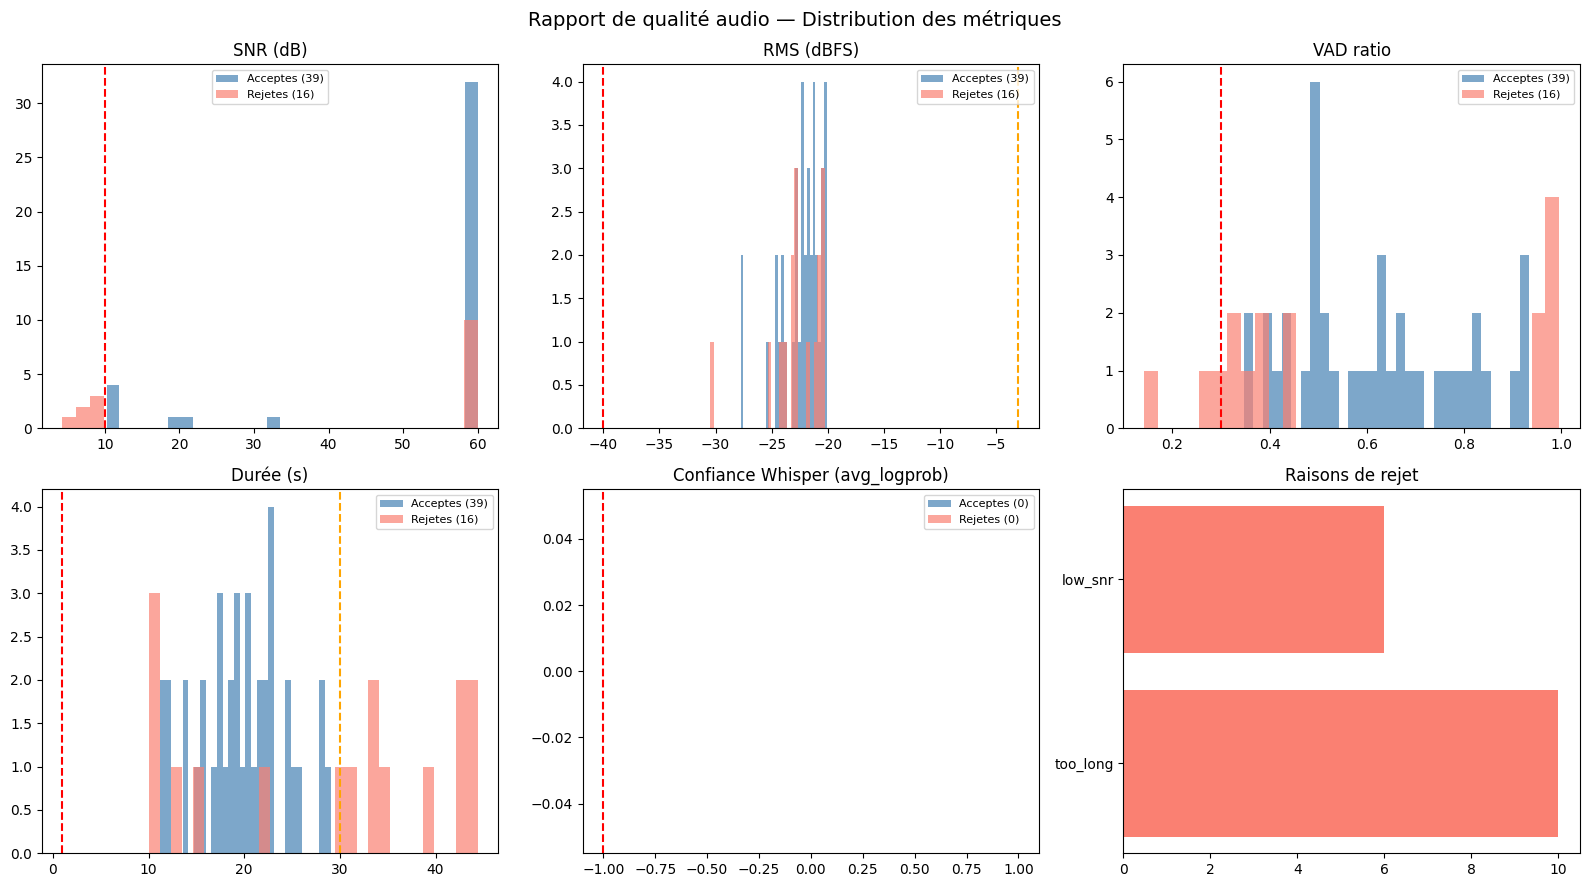

Rapport sauvegardé : /content/drive/MyDrive/asr/output_2/preprocessed/quality_report.png
CSV sauvegardé     : /content/drive/MyDrive/asr/output_2/preprocessed/quality_report.csv


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Rapport de qualité audio — Distribution des métriques', fontsize=14)

plots = [
    ('snr_db',        'SNR (dB)',          CONFIG['min_snr_db'],   None),
    ('rms_db',        'RMS (dBFS)',         CONFIG['min_rms_db'],   CONFIG['max_rms_db']),
    ('vad_ratio',     'VAD ratio',          CONFIG['min_vad_ratio'], None),
    ('duration_sec',  'Durée (s)',          CONFIG['min_duration_sec'], CONFIG['max_duration_sec']),
    ('avg_logprob',   'Confiance Whisper (avg_logprob)', CONFIG.get('min_avg_logprob', -1.0), None),
]

for ax, (col, label, lo, hi) in zip(axes.flatten()[:5], plots):
    if col not in quality_df.columns:
        ax.set_title(f'{label} (N/A)')
        continue
    d_pass = quality_df[quality_df['passed']][col].dropna()
    d_rej  = quality_df[~quality_df['passed']][col].dropna()
    ax.hist(d_pass, bins=30, alpha=0.7, color='steelblue', label=f'Acceptes ({len(d_pass)})')
    ax.hist(d_rej,  bins=30, alpha=0.7, color='salmon',    label=f'Rejetes ({len(d_rej)})')
    if lo is not None: ax.axvline(lo, color='red',    linestyle='--', linewidth=1.5)
    if hi is not None: ax.axvline(hi, color='orange', linestyle='--', linewidth=1.5)
    ax.set_title(label)
    ax.legend(fontsize=8)

ax_rej = axes[1][2]
reasons = quality_df[~quality_df['passed']]['reject_reason']
counts  = reasons.str.split('(').str[0].str.strip().value_counts()
if not counts.empty:
    ax_rej.barh(counts.index, counts.values, color='salmon')
    ax_rej.set_title('Raisons de rejet')

plt.tight_layout()
viz_path = CONFIG['output_dir'] / 'quality_report.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Rapport sauvegardé : {viz_path}')

csv_path = CONFIG['output_dir'] / 'quality_report.csv'
quality_df.to_csv(csv_path, index=False)
print(f'CSV sauvegardé     : {csv_path}')

---
## Zone D : Augmentation des données (automatique via `audiomentations`)

Pour chaque segment validé, `N` versions augmentées sont générées **automatiquement**
via la librairie open-source [`audiomentations`](https://github.com/iver56/audiomentations)
(inspirée d'albumentations, activement maintenue, compatible CPU & GPU).

Le texte de référence est **identique** pour toutes les versions — seul l'audio change.

**Pourquoi `audiomentations` ?**
- Couvre toutes les transformations de notre pipeline précédent
  (bruit, RIR, time-stretch, pitch-shift, volume) en une seule API déclarative.
- Plus besoin de coder manuellement les transformations : `Compose` / `OneOf` / `SomeOf`
  gèrent la sélection et l'enchaînement aléatoire.
- `RoomSimulator` intégré (simulation acoustique, remplace nos RIR maison).
- `AddBackgroundNoise` supporte les dossiers de bruit réel (MUSAN, FreeSound…).
- Variante GPU : `torch-audiomentations` pour les gros datasets.

Transformations actives :
- `AddGaussianSNR` — bruit blanc à SNR contrôlé (5–20 dB)
- `AddColoredNoise` — bruit rose / coloré
- `RoomSimulator` — simulation acoustique (petite/moyenne/grande pièce)
- `TimeStretch` — modification du tempo (±10%), préserve la hauteur
- `PitchShift` — modification de la hauteur (±2 demi-tons)
- `Gain` — perturbation du volume (±6 dB)
- `Mp3Compression` — simulation de compression codec (dégradation réaliste)
- `SomeOf` — combinaison aléatoire de 2 techniques parmi les précédentes

In [16]:
from audiomentations import (
    Compose, OneOf, SomeOf,
    AddGaussianSNR,
    RoomSimulator,
    TimeStretch, PitchShift,
    Gain, Mp3Compression,
    ApplyImpulseResponse,
)


class AudioAugmenter:
    """
    Augmentation automatique via audiomentations.
    Chaque appel à augment_batch() génère N variantes par segment.
    """

    def __init__(self, aug_dir: Path, sr: int = 16000, seed: int = 42):
        self.aug_dir = aug_dir
        self.sr      = sr
        self.rng     = np.random.default_rng(seed)
        self.aug_dir.mkdir(parents=True, exist_ok=True)

        # ── Pipeline d'augmentation déclaratif ──────────────────────────────
        # SomeOf(N) choisit N transformations aléatoires parmi la liste.
        # p=1.0 sur SomeOf = toujours appliquer au moins une transformation.
        self._augment_pipeline = SomeOf(
            num_transforms=2,
            transforms=[
                # Bruit gaussien à SNR contrôlé
                AddGaussianSNR(
                    min_snr_db=CONFIG['snr_range_db'][0],
                    max_snr_db=CONFIG['snr_range_db'][1],
                    p=1.0
                ),
                # Simulation acoustique de pièce (RIR synthétique)
                RoomSimulator(
                    min_size_x=3.6, max_size_x=10.0,
                    min_size_y=3.6, max_size_y=10.0,
                    min_size_z=2.4, max_size_z=4.0,
                    min_source_x=0.1, max_source_x=3.5,
                    min_source_y=0.1, max_source_y=3.5,
                    use_ray_tracing=True,
                    max_order=1,
                    leave_length_unchanged=True,
                    p=1.0
                ),
                # Modification tempo (préserve hauteur)
                TimeStretch(
                    min_rate=CONFIG['speed_range'][0],
                    max_rate=CONFIG['speed_range'][1],
                    leave_length_unchanged=False,
                    p=1.0
                ),
                # Modification hauteur
                PitchShift(
                    min_semitones=CONFIG['pitch_range_steps'][0],
                    max_semitones=CONFIG['pitch_range_steps'][1],
                    p=1.0
                ),
                # Perturbation volume
                Gain(
                    min_gain_db=-6.0,
                    max_gain_db=6.0,
                    p=1.0
                ),
                # Compression MP3 (simulation dégradation codec)
                Mp3Compression(
                    min_bitrate=32,
                    max_bitrate=96,
                    p=1.0
                ),
            ],
            p=1.0,
        )

    def augment(self, audio: np.ndarray) -> np.ndarray:
        """Applique le pipeline SomeOf(2) sur un signal numpy float32."""
        return self._augment_pipeline(
            samples=audio.astype(np.float32),
            sample_rate=self.sr
        )

    def augment_batch(self, pairs: List[Dict],
                      n_augments: int = 3) -> List[Dict]:
        """
        Génère N versions augmentées par segment.
        Les versions originales sont aussi incluses dans la sortie.
        """
        print('=' * 70)
        print('ZONE D : AUGMENTATION DES DONNÉES (audiomentations)')
        print('=' * 70)
        print(f'   Segments originaux : {len(pairs)}')
        print(f'   Augmentations/seg  : {n_augments}')
        print(f'   Total attendu      : {len(pairs) * (1 + n_augments)}')
        print()

        all_pairs = list(pairs)  # Garder les originaux

        for pair in tqdm(pairs, desc='Augmentation'):
            audio_path = Path(pair['audio_path'])
            try:
                audio, _ = librosa.load(str(audio_path),
                                         sr=self.sr, mono=True)
            except Exception:
                continue

            for i in range(n_augments):
                aug_id   = f"{pair['id']}_aug{i:02d}"
                out_path = self.aug_dir / (aug_id + '.wav')

                if not out_path.exists():
                    try:
                        aug_audio = self.augment(audio)
                        sf.write(str(out_path), aug_audio, self.sr,
                                 subtype='PCM_16')
                    except Exception as e:
                        print(f'  aug error (seg {pair["id"]}): {e}')
                        continue

                aug_pair = dict(pair)
                aug_pair['id']           = aug_id
                aug_pair['audio_path']   = out_path
                aug_pair['is_augmented'] = True
                aug_pair['aug_strategy'] = 'audiomentations_someof2'
                all_pairs.append(aug_pair)

        orig  = len(pairs)
        total = len(all_pairs)
        print(f'\n   Originaux       : {orig}')
        print(f'   Augmentes       : {total - orig}')
        print(f'   Total dataset   : {total}')
        return all_pairs


augmenter  = AudioAugmenter(
    aug_dir=CONFIG['augmented_dir'],
    sr=CONFIG['sample_rate']
)
pairs_augmented = augmenter.augment_batch(
    pairs_passed,
    n_augments=CONFIG['augmentation_factor']
)

ZONE D : AUGMENTATION DES DONNÉES (audiomentations)
   Segments originaux : 39
   Augmentations/seg  : 3
   Total attendu      : 156



Augmentation:   0%|          | 0/39 [00:00<?, ?it/s]Failed to import fast_mp3_augment. Maybe it is not installed? To install the optional fast_mp3_augment dependency of audiomentations, run `pip install audiomentations[extras]` or simply `pip install fast_mp3_augment`
Failed to import pyroomacoustics. Maybe it is not installed? To install the optional pyroomacoustics dependency of audiomentations, do `pip install audiomentations[extras]` or simply  `pip install pyroomacoustics`
Augmentation:   3%|▎         | 1/39 [00:00<00:05,  6.41it/s]

  aug error (seg merged_01-1b_SOF_0000): No module named 'fast_mp3_augment'
  aug error (seg merged_01-1b_SOF_0000): No module named 'pyroomacoustics'


Failed to import fast_mp3_augment. Maybe it is not installed? To install the optional fast_mp3_augment dependency of audiomentations, run `pip install audiomentations[extras]` or simply `pip install fast_mp3_augment`
Augmentation:   5%|▌         | 2/39 [00:00<00:06,  6.15it/s]

  aug error (seg merged_01-2_KAT_0001): No module named 'fast_mp3_augment'


...

  aug error (seg merged_01-3d_KAT_0053): No module named 'fast_mp3_augment'


Augmentation:  90%|████████▉ | 35/39 [00:06<00:00,  5.24it/s]Failed to import pyroomacoustics. Maybe it is not installed? To install the optional pyroomacoustics dependency of audiomentations, do `pip install audiomentations[extras]` or simply  `pip install pyroomacoustics`
Failed to import fast_mp3_augment. Maybe it is not installed? To install the optional fast_mp3_augment dependency of audiomentations, run `pip install audiomentations[extras]` or simply `pip install fast_mp3_augment`
Failed to import fast_mp3_augment. Maybe it is not installed? To install the optional fast_mp3_augment dependency of audiomentations, run `pip install audiomentations[extras]` or simply `pip install fast_mp3_augment`
Augmentation:  92%|█████████▏| 36/39 [00:06<00:00,  5.66it/s]

  aug error (seg merged_01-3d_KAT_0055): No module named 'pyroomacoustics'
  aug error (seg merged_01-3d_KAT_0055): No module named 'fast_mp3_augment'
  aug error (seg merged_01-3d_KAT_0055): No module named 'fast_mp3_augment'


Augmentation:  95%|█████████▍| 37/39 [00:06<00:00,  4.07it/s]Failed to import pyroomacoustics. Maybe it is not installed? To install the optional pyroomacoustics dependency of audiomentations, do `pip install audiomentations[extras]` or simply  `pip install pyroomacoustics`
Failed to import fast_mp3_augment. Maybe it is not installed? To install the optional fast_mp3_augment dependency of audiomentations, run `pip install audiomentations[extras]` or simply `pip install fast_mp3_augment`
Failed to import pyroomacoustics. Maybe it is not installed? To install the optional pyroomacoustics dependency of audiomentations, do `pip install audiomentations[extras]` or simply  `pip install pyroomacoustics`
Augmentation: 100%|██████████| 39/39 [00:06<00:00,  5.70it/s]

  aug error (seg merged_01-3d_KAT_0057): No module named 'pyroomacoustics'
  aug error (seg merged_01-4_KAT_0058): No module named 'fast_mp3_augment'
  aug error (seg merged_01-4_KAT_0058): No module named 'pyroomacoustics'

   Originaux       : 39
   Augmentes       : 79
   Total dataset   : 118


---
## Zone E : Export JSONL — Dataset final pour Whisper

In [17]:
import random

def export_jsonl(pairs: List[Dict], out_dir: Path,
                 train_ratio: float = 0.85) -> Dict[str, Path]:
    """
    Exporte le dataset en JSONL avec split train/validation.

    Format de sortie par ligne :
        {
            "audio_path": "/chemin/vers/audio.wav",
            "text": "transcription de référence",
            "id": "segment_id",
            "speaker": "speaker_id",
            "is_augmented": false,
            "aug_strategy": null,
            "quality": {"snr_db": 18.2, "rms_db": -22.1, ...}
        }
    """
    print('=' * 70)
    print('ZONE E : EXPORT JSONL')
    print('=' * 70)

    # Séparer originaux / augmentés pour un split équitable
    originals  = [p for p in pairs if not p.get('is_augmented', False)]
    augmented  = [p for p in pairs if p.get('is_augmented', False)]

    random.shuffle(originals)
    split_idx  = int(len(originals) * train_ratio)
    train_ids  = {p['id'] for p in originals[:split_idx]}

    train_pairs = [p for p in pairs
                   if p['id'] in train_ids or
                   (p.get('is_augmented') and
                    # L'augmenté suit son original
                    '_aug' in p['id'] and
                    p['id'].rsplit('_aug', 1)[0] in train_ids)]
    val_pairs   = [p for p in originals if p['id'] not in train_ids]

    def write(path: Path, data: List[Dict]):
        with open(path, 'w', encoding='utf-8') as f:
            for p in data:
                row = {
                    'audio_path'   : str(p['audio_path']),
                    'text'         : p.get('text', ''),
                    'id'           : p.get('id', ''),
                    'speaker'      : p.get('speaker', 'unknown'),
                    'is_augmented' : p.get('is_augmented', False),
                    'aug_strategy' : p.get('aug_strategy', None),
                    'sep_method'   : p.get('sep_method', None),
                    'quality'      : p.get('quality', {}),
                }
                f.write(json.dumps(row, ensure_ascii=False) + '\n')

    train_path = out_dir / 'train.jsonl'
    val_path   = out_dir / 'validation.jsonl'

    write(train_path, train_pairs)
    write(val_path,   val_pairs)

    # Sauvegarder aussi les rejetés pour audit
    reject_path = out_dir / 'rejected.jsonl'
    quality_df.to_json(reject_path, orient='records', lines=True, force_ascii=False)

    print(f'\n   Train      : {len(train_pairs):>6} segments  → {train_path}')
    print(f'   Validation : {len(val_pairs):>6} segments  → {val_path}')
    print(f'   Rejetés    : {len(pairs_rejected):>6} segments  → {reject_path}')

    return {'train': train_path, 'validation': val_path, 'rejected': reject_path}


output_files = export_jsonl(
    pairs_augmented,
    out_dir=CONFIG['output_dir'],
    train_ratio=0.85
)

ZONE E : EXPORT JSONL

   Train      :    101 segments  → /content/drive/MyDrive/asr/output_2/preprocessed/train.jsonl
   Validation :      6 segments  → /content/drive/MyDrive/asr/output_2/preprocessed/validation.jsonl
   Rejetés    :     16 segments  → /content/drive/MyDrive/asr/output_2/preprocessed/rejected.jsonl
